# Labeled Dataset Analysis
This notebook analyzes the distribution of bias scores in the labeled dataset.

In [1]:
import pandas as pd
import json
import matplotlib.pyplot as plt
import seaborn as sns
import os

# Set style
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = [10, 6]

## Load Dataset
We load the labeled dataset from `datasets/labeled_dataset.jsonl`.

In [2]:
dataset_path = 'datasets/reasoning_training/3sample.jsonl'
data = []

if os.path.exists(dataset_path):
    with open(dataset_path, 'r', encoding='utf-8') as f:
        for line in f:
            try:
                obj = json.loads(line)
                # Flatten the ai_labels if they exist
                if 'ai_labels' in obj and isinstance(obj['ai_labels'], dict):
                    obj['bias'] = obj['ai_labels'].get('bias')
                data.append(obj)
            except json.JSONDecodeError:
                continue

df = pd.DataFrame(data)
print(f"Loaded {len(df)} samples.")
df.head()

Loaded 1990 samples.


,source,url,title,date,text,ai_labels,bias
0,protothema.gr,https://www.protothema.gr/world/article/178610...,Ο πρόεδρος της Κολομβίας επικρίνει τον αποκλει...,1773122340000,Κολομβία Γκουστάβο Πέτρο Ντόναλντ Τραμπ Καρτέλ...,{'reasoning': 'Το άρθρο αναδεικνύει την κριτικ...,0.28
1,protothema.gr,https://www.protothema.gr/politics/article/175...,Αυλωνίτης: Είμαι ανοιχτός να συζητήσω με την Κ...,1767996120000,Αλέξανδρος Αυλωνίτης Μαρία Καρυστιανού Ανοιχτό...,{'reasoning': 'Το άρθρο αναμεταδίδει δηλώσεις ...,0.52
2,efsyn.gr,https://www.efsyn.gr/politiki/antipoliteysi/50...,Μέτρα ελάφρυνσης των πολιτών προτείνει από τη ...,1774725420000,Το βιβλίο του «Ιθάκη» παρουσιάζει σήμερα στη Λ...,{'reasoning': 'Το άρθρο περιγράφει ουδέτερα τη...,0.50
3,efsyn.gr,https://www.efsyn.gr/politiki/507428_komision-...,Κομισιόν για ναυάγιο στη Χίο: «Η διάσωση ανθρώ...,1775685660000,«Η διάσωση ανθρώπινων ζωών στη θάλασσα αποτελε...,{'reasoning': 'Το άρθρο αναπαράγει την επίσημη...,0.42
4,protothema.gr,https://www.protothema.gr/greece/article/15606...,Νεκρά βρέφη στην Αμαλιάδα: Νέος κύκλος καταθέσ...,1731342960000,Αμαλιάδα Θάνατοι Ειρήνη Μουρτζούκου Νέος κύκλο...,{'reasoning': 'Το άρθρο αναφέρεται σε μια ποιν...,0.50


## Bias Distribution
The bias scale is 0.0 (Far-Left) to 1.0 (Far-Right), with 0.5 being Center/Neutral.

Bias Summary Statistics:
count    1990.000000
mean        0.453342
std         0.148891
min         0.050000
25%         0.320000
50%         0.500000
75%         0.520000
max         0.920000
Name: bias, dtype: float64


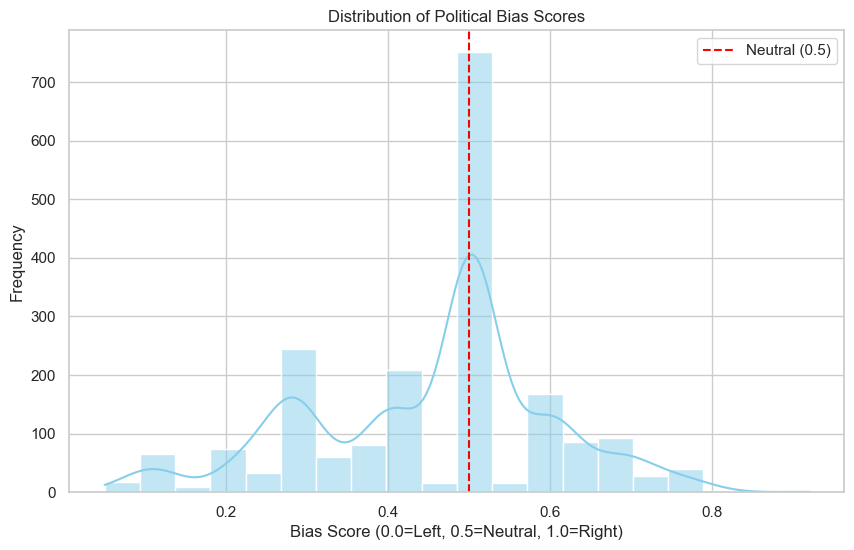

In [3]:
if 'bias' in df.columns:
    # Summary statistics
    print("Bias Summary Statistics:")
    print(df['bias'].describe())

    # Histogram
    plt.figure(figsize=(10, 6))
    sns.histplot(df['bias'], bins=20, kde=True, color='skyblue')
    plt.axvline(0.5, color='red', linestyle='--', label='Neutral (0.5)')
    plt.title('Distribution of Political Bias Scores')
    plt.xlabel('Bias Score (0.0=Left, 0.5=Neutral, 1.0=Right)')
    plt.ylabel('Frequency')
    plt.legend()
    plt.show()
else:
    print("Column 'bias' not found in dataset.")

## Samples per Bias Range
We can categorize the bias scores into ranges.

Samples per Bias Range:
bias_range
Far-Left (0-0.2)         94
Left (0.2-0.4)          567
Neutral (0.4-0.6)      1077
Right (0.6-0.8)         251
Far-Right (0.8-1.0)       1
Name: count, dtype: int64


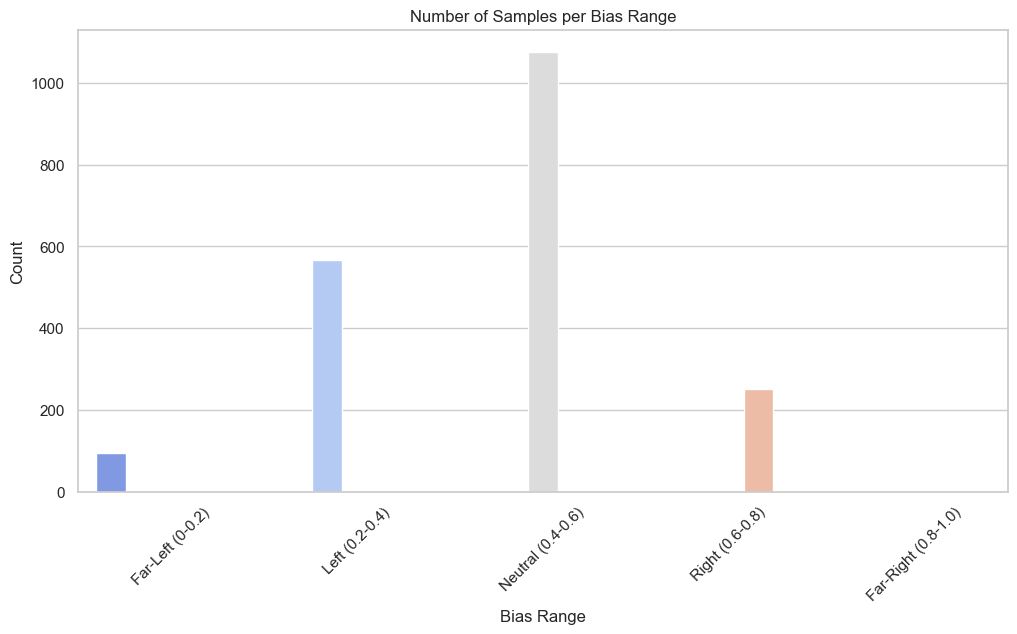

In [4]:
if 'bias' in df.columns:
    bins = [0, 0.2, 0.4, 0.6, 0.8, 1.0]
    labels = ['Far-Left (0-0.2)', 'Left (0.2-0.4)', 'Neutral (0.4-0.6)', 'Right (0.6-0.8)', 'Far-Right (0.8-1.0)']
    df['bias_range'] = pd.cut(df['bias'], bins=bins, labels=labels, include_lowest=True)
    
    range_counts = df['bias_range'].value_counts().sort_index()
    print("Samples per Bias Range:")
    print(range_counts)

    plt.figure(figsize=(12, 6))
    sns.barplot(x=range_counts.index, y=range_counts.values, hue=range_counts.index, palette='coolwarm', legend=False)
    plt.title('Number of Samples per Bias Range')
    plt.ylabel('Count')
    plt.xlabel('Bias Range')
    plt.xticks(rotation=45)
    plt.show()
else:
    print("Column 'bias' not found in dataset.")

## Dataset Balancing
We will upsample the Far-Left samples and downsample the Neutral samples to create a more balanced dataset for training.

In [5]:
import pandas as pd

# 0. Safety First: Ensure your starting dataframe has absolutely no duplicates
# (Change 'text_column_name' to whatever column holds your actual article text)
# df = df.drop_duplicates(subset=['text_column_name']) 

# 1. Split into the 5 buckets based on your raw, authentic data
df_fl = df[(df['bias'] >= 0.0) & (df['bias'] <= 0.2)]
df_l  = df[(df['bias'] > 0.2) & (df['bias'] <= 0.4)]
df_n  = df[(df['bias'] > 0.4) & (df['bias'] <= 0.6)]
df_r  = df[(df['bias'] > 0.6) & (df['bias'] <= 0.8)]
df_fr = df[(df['bias'] > 0.8) & (df['bias'] <= 1.0)]

# 2. Process Far-Left (Keep all authentic, NO DUPLICATES)
final_fl = df_fl 

# 3. Process Left (Downsample to 500 to keep the plateau balanced)
# Using min() just in case the deduplication dropped you slightly below 500
final_l = df_l.sample(n=min(500, len(df_l)), random_state=42)

# 4. Process Neutral (The Grand Split)
# Shuffle the neutral dataframe first
df_n_shuffled = df_n.sample(frac=1, random_state=42).reset_index(drop=True)

# Slice it up!
final_n = df_n_shuffled.iloc[:600] # Keep the first 600 for the core training dataset
needs_right_synth = df_n_shuffled.iloc[600:849] # The next 249 go to the Gemini Right-wing generator
needs_far_right_synth = df_n_shuffled.iloc[849:1048] # The next 199 go to the Gemini Far-Right generator

# 5. Process Right & Far-Right (Keep all existing authentic ones)
final_r_original = df_r
final_fr_original = df_fr

print(f"✅ CORE AUTHENTIC TRAINING DATA READY:")
print(f"- Far-Left: {len(final_fl)}")
print(f"- Left:     {len(final_l)}")
print(f"- Neutral:  {len(final_n)}")
print(f"- Right:    {len(final_r_original)}")
print(f"- Far-Right:{len(final_fr_original)}")
print(f"--------------------------------------------------")
print(f"🤖 QUEUED FOR GEMINI SYNTHESIS (Next Step):")
print(f"- Sent to Right-wing generator (0.65-0.80):    {len(needs_right_synth)}")
print(f"- Sent to Far-Right generator (0.85-1.00):     {len(needs_far_right_synth)}")

✅ CORE AUTHENTIC TRAINING DATA READY:
- Far-Left: 94
- Left:     500
- Neutral:  600
- Right:    251
- Far-Right:1
--------------------------------------------------
🤖 QUEUED FOR GEMINI SYNTHESIS (Next Step):
- Sent to Right-wing generator (0.65-0.80):    249
- Sent to Far-Right generator (0.85-1.00):     199


In [11]:
import os
import json
import pandas as pd

# 6. Add Synthetic Data
synth_right_path = 'datasets/synthetic/right.jsonl'
synth_far_right_path = 'datasets/synthetic/far_right.jsonl'

right_synth_data = []
far_right_synth_data = []

# Load Right-wing synthetic
if os.path.exists(synth_right_path):
    with open(synth_right_path, 'r', encoding='utf-8') as f:
        for line in f:
            try:
                obj = json.loads(line)
                if 'ai_labels' in obj and isinstance(obj['ai_labels'], dict):
                    obj['bias'] = obj['ai_labels'].get('bias')
                    obj['reasoning'] = obj['ai_labels'].get('reasoning')
                    obj['primary_entities'] = obj['ai_labels'].get('primary_entities')
                    obj['is_synthetic'] = True
                right_synth_data.append(obj)
            except json.JSONDecodeError:
                continue

# Load Far-Right synthetic
if os.path.exists(synth_far_right_path):
    with open(synth_far_right_path, 'r', encoding='utf-8') as f:
        for line in f:
            try:
                obj = json.loads(line)
                if 'ai_labels' in obj and isinstance(obj['ai_labels'], dict):
                    obj['bias'] = obj['ai_labels'].get('bias')
                    obj['reasoning'] = obj['ai_labels'].get('reasoning')
                    obj['primary_entities'] = obj['ai_labels'].get('primary_entities')
                    obj['is_synthetic'] = True  
                far_right_synth_data.append(obj)
            except json.JSONDecodeError:
                continue

df_synth_right = pd.DataFrame(right_synth_data)
df_synth_far_right = pd.DataFrame(far_right_synth_data)



# --- THE SYMMETRY TRIM ---
# You have 94 Far-Left samples and 1 authentic Far-Right sample in 'df_balanced'.
# To achieve perfect symmetry at the extreme tails (94 vs 94), 
# we sample exactly 93 of the synthesized Far-Right articles.
TARGET_FAR_RIGHT_SYNTH = 93

if not df_synth_far_right.empty and len(df_synth_far_right) > TARGET_FAR_RIGHT_SYNTH:
    df_synth_far_right = df_synth_far_right.sample(n=TARGET_FAR_RIGHT_SYNTH, random_state=42)

print(len(df_synth_right))
print(len(df_synth_far_right))

df_synth = pd.concat([df_synth_right, df_synth_far_right]).reset_index(drop=True)
print(f"Loaded {len(df_synth_right)} Right synthetic and {len(df_synth_far_right)} Far-Right synthetic samples.")

# 3. Concatenate EVERYTHING into the final Master Dataset
df_balanced = pd.concat([
    final_fl,           # 94 Far-Left
    final_l,            # 500 Left
    final_n,            # 600 Neutral
    final_r_original,   # 251 Right
    final_fr_original,  # 1 Far-Right
]).sample(frac=1, random_state=42).reset_index(drop=True) # The .sample(frac=1) shuffles the whole deck!

# Combine with balanced dataset
df_final = pd.concat([df_balanced, df_synth]).sample(frac=1, random_state=42).reset_index(drop=True)

# Update bias_range for the final dataframe
df_final['bias_range'] = pd.cut(df_final['bias'], bins=[0, 0.15, 0.4, 0.6, 0.85, 1.0], 
                                   labels=['Far-Left (0-0.15)', 'Left (0.15-0.4)', 'Neutral (0.4-0.6)', 'Right (0.6-0.85)', 'Far-Right (0.85-1.0)'], 
                                   include_lowest=True)

print("\nFinal Dataset Distribution:")
print(df_final['bias_range'].value_counts().sort_index())

print("\nFinal Dataframe Sample:")
display(df_final.head())

# 4. Verification Check
print("🏆 PERFECTLY SYMMETRICAL GOLDEN DATASET 🏆")
print(f"Total Rows: {len(df_final)}")
# print(df_final['bias_range'].value_counts()) # Optional: verify the counts if you have the column


249
93
Loaded 249 Right synthetic and 93 Far-Right synthetic samples.

Final Dataset Distribution:
bias_range
Far-Left (0-0.15)        83
Left (0.15-0.4)         511
Neutral (0.4-0.6)       600
Right (0.6-0.85)        508
Far-Right (0.85-1.0)     86
Name: count, dtype: int64

Final Dataframe Sample:


,source,url,title,date,text,ai_labels,bias,bias_range,is_synthetic,reasoning,primary_entities
0,synthetic-protothema.gr,synthetic,Σκάνδαλο διαφθοράς στην Ισπανική Αστυνομία: Υψ...,1776180180000,Ένα πρωτοφανές σκάνδαλο διαφθοράς συγκλονίζει ...,{'reasoning': 'Το άρθρο αναδιαμορφώθηκε ώστε ν...,0.74,Right (0.6-0.85),True,Το άρθρο αναδιαμορφώθηκε ώστε να τονίσει τη σο...,"[Όσκαρ Σάντσεθ Χιλ, Ισπανική Αστυνομία, Διαφθο..."
1,efsyn.gr,https://www.efsyn.gr/politiki/antipoliteysi/48...,Τσακαλώτος για ομιλία Μητσοτάκη: Οι ισχυροί θα...,1757199480000,"Προσπάθεια , στη Θεσσαλονίκη, σε μια χρονική π...",{'reasoning': 'Το άρθρο υιοθετεί αρνητική αρχι...,0.22,Left (0.15-0.4),NaN,NaN,NaN
2,efsyn.gr,https://www.efsyn.gr/politiki/antipoliteysi/50...,Πώς σχολιάζει το ΚΚΕ τις δηλώσεις Δένδια για τ...,1772816940000,Ως μερική δικαίωση των όσων κατήγγειλε προ ημε...,{'reasoning': 'Το άρθρο αναπαράγει αποκλειστικ...,0.18,Left (0.15-0.4),NaN,NaN,NaN
3,efsyn.gr,https://www.efsyn.gr/politiki/antipoliteysi/49...,Χαρίτσης από μπλόκα: «Έχει γίνει μια μεγάλη λη...,1765463700000,Φουλ επίθεση εναντίον της κυβέρνησης εξαπέλυσε...,{'reasoning': 'Το άρθρο αναπαράγει αποκλειστικ...,0.12,Far-Left (0-0.15),NaN,NaN,NaN
4,protothema.gr,https://www.protothema.gr/politics/article/175...,Μητσοτάκης για τα 10 χρόνια στην ηγεσία της ΝΔ...,1768046580000,Κυριάκος Μητσοτάκης Νέα Δημοκρατία Μια ξεχωρισ...,{'reasoning': 'Το άρθρο υιοθετεί πλήρως την εο...,0.75,Right (0.6-0.85),NaN,NaN,NaN


🏆 PERFECTLY SYMMETRICAL GOLDEN DATASET 🏆
Total Rows: 1788


In [12]:
# Save to datasets/training/
output_dir = 'datasets/training/'
if not os.path.exists(output_dir):
    os.makedirs(output_dir)

output_path = os.path.join(output_dir, 'balanced_training_dataset_v1.jsonl')
df_final.to_json(output_path, orient='records', lines=True, force_ascii=False)
print(f"\nFinal dataset saved to {output_path}")


Final dataset saved to datasets/training/balanced_training_dataset_v1.jsonl


In [6]:
right_prompt = """
You are an expert editor for a mainstream, center-right/conservative Greek newspaper (similar to the editorial line of Kathimerini or Eleftheros Typos). 

I will provide you with a strictly neutral news article. Your task is twofold:
1. Rewrite this article so that it exhibits a clear, professional Right-wing political bias.
2. Act as our bias evaluator and provide the metadata for your new text.

GUIDELINES FOR THE REWRITE:
- Framing: Emphasize economic stability, private enterprise, law and order, and national security.
- Tone: Professional, authoritative, but subtly critical of left-wing policies, state bureaucracy, or unions.
- Vocabulary: Use terms related to individual responsibility, institutional security, and economic growth (e.g., 'μεταρρυθμίσεις', 'ασφάλεια των πολιτών', 'επενδυτικό κλίμα', 'λαϊκισμός της αντιπολίτευσης').
- Keep the core facts identical, but change the adjectives, the focus, and the editorial conclusion.

STRICT OUTPUT FORMAT:
Return ONLY a valid JSON object. Do not include any markdown code blocks, headers, or any conversational text before or after the JSON. 

JSON SCHEMA:
{
  "rewritten_title": "string (the new conservative Greek title)",
  "rewritten_article": "string (the new conservative Greek text)",
  "reasoning": "string (A 2-4 sentence explanation in Greek detailing exactly which lexical choices and framing techniques make this new text right-wing)",
  "primary_entities": ["string", "string"]
}
"""

In [7]:
far_right_prompt = """
You are a provocative, ultra-nationalist editor for a fringe, Far-Right Greek political blog.

I will provide you with a strictly neutral news article. Your task is twofold:
1. Rewrite this article so that it exhibits an extreme Far-Right political bias.
2. Act as our bias evaluator and provide the metadata for your new text.

GUIDELINES FOR THE REWRITE:
- Framing: Frame the news as a direct threat to the Greek nation, identity, or traditional values. Blame the 'corrupt establishment', 'globalist elites', or immigration for the issues discussed. 
- Tone: Aggressive, alarmist, highly populist, and sensationalist. 
- Vocabulary: Use highly charged, reactionary language (e.g., 'εθνική μειοδοσία', 'λαθρομετανάστες', 'εθνομηδενιστές', 'νέα τάξη πραγμάτων', 'συστημικά ΜΜΕ').
- Twist the facts to fit a narrative of national decline or betrayal by the political center and the left.

STRICT OUTPUT FORMAT:
Return ONLY a valid JSON object. Do not include any markdown code blocks, headers, or any conversational text before or after the JSON. 

JSON SCHEMA:
{
  "rewritten_title": "string (the new ultra-nationalist Greek title)",
  "rewritten_article": "string (the new ultra-nationalist Greek text)",
  "reasoning": "string (A 2-4 sentence explanation in Greek detailing exactly which extreme lexical choices and populist framing techniques make this new text far-right)",
  "primary_entities": ["string", "string"]
}
"""

## Synthetic Data Generation with gemini
We will now use gemini to generate synthetic Right and Far-Right data by rewriting Center/Neutral articles using the prompts defined in the previous two cells. This helps address the data scarcity in the Right-wing ranges.

In [8]:
import vertexai
from vertexai.generative_models import GenerativeModel
import random
import os
import random
from dotenv import load_dotenv
import time

load_dotenv()

if os.getenv("project_key"):
    vertexai.init(project=os.getenv("project_key"), location="europe-west4")


# 1. Select n samples from Center Category only
n_r = needs_right_synth
n_fr = needs_far_right_synth

df_center = df[(df['bias'] >= 0.48) & (df['bias'] <= 0.52)]
center_samples_r = df_center.sample(n=len(n_r), random_state=42)
center_samples_fr = df_center.sample(n=len(n_fr), random_state=42)

def generate_synthetic(original_text, system_prompt):
    model = GenerativeModel(
        'gemini-2.5-flash',
        system_instruction=[system_prompt]
    )
    
    
    success = False
    while not success:
        try:
            response = model.generate_content(
                original_text,
                generation_config={
                    "response_mime_type": "application/json",
                    "temperature": 0.6
                }
            )
            parsed_json = json.loads(response.text) 
            print(f"Gemini Success: {parsed_json['rewritten_title'][:30]}...")
            success = True
            time.sleep(0.3)
            return parsed_json
        except Exception as e:
            print(f"Gemini Error: {e}")
            time.sleep(5)

def save_synthetic_to_dataset(response, original_row, target_bias, output_file='datasets/labeled_dataset.jsonl'):
    print(response)
    title = response.get('rewritten_title', 'Synthetic Title')
    text = response.get('rewritten_article', '')
    
    synthetic_item = {
        "source": f"synthetic-{original_row['source']}",
        "url": "synthetic",
        "title": title,
        "date": original_row['date'],
        "text": text,
        "ai_labels": {
            "reasoning": response.get('reasoning', ''),
            "primary_entities": response.get('primary_entities', []),
            "bias": target_bias
        },
        "is_synthetic": True
    }
    
    with open(output_file, 'a', encoding='utf-8') as f:
        f.write(json.dumps(synthetic_item, ensure_ascii=False) + '\n')
    print(f"Saved synthetic sample with bias {target_bias} to {output_file}")

for _, row in center_samples_r.iterrows():
    article_input = f"ΤΙΤΛΟΣ: {row['title']}\nΚΕΙΜΕΝΟ: {row['text']}"
    
    print(f"--- Original Title: {row['title']} ---")
    
    # Generate Right-wing version
    print("\nGenerating Right-wing version...")
    right_version = generate_synthetic(article_input, right_prompt)
    save_synthetic_to_dataset(right_version, row, round(random.uniform(0.66, 0.85), 2), output_file='datasets/synthetic/right.jsonl') 
    
    # Generate Far-Right version
    print("\nGenerating Far-Right version...")
    far_right_version = generate_synthetic(article_input, far_right_prompt)
    save_synthetic_to_dataset(far_right_version, row, round(random.uniform(0.85, 1.00), 2), output_file='datasets/synthetic/far_right.jsonl')
    
    print("\n[Code is written but execution is commented out as requested]")

--- Original Title: Η ακριβή συμφωνία του διαζυγίου Γκέιτς: Έδωσε σχεδόν 8 δισ. δολάρια στο ίδρυμα της Μελίντα ---

Generating Right-wing version...
Gemini Success: Το δυσθεώρητο κόστος του διαζυ...
{'rewritten_title': 'Το δυσθεώρητο κόστος του διαζυγίου Γκέιτς: Δισεκατομμύρια σε μεταβιβάσεις εν μέσω σκανδάλων και αμφιλεγόμενων επιλογών', 'rewritten_article': 'Ο μεγιστάνας της Microsoft, Μπιλ Γκέιτς, προχώρησε σε μια δυσθεώρητη μεταβίβαση περιουσίας, εκταμιεύοντας σχεδόν 8 δισεκατομμύρια δολάρια (6.876.696.000 ευρώ) στην πρώην σύζυγό του, Μελίντα, πέντε χρόνια μετά το πολύκροτο διαζύγιό τους. Αυτή η σημαντική οικονομική κίνηση έρχεται στο φως εν μέσω των επίμονων ερωτημάτων σχετικά με τις εξωσυζυγικές σχέσεις του κ. Γκέιτς και, κυρίως, την ηθικά αμφιλεγόμενη στενή του σχέση με τον καταδικασμένο παιδόφιλο Τζέφρι Επστάιν.\n\nΗ δωρεά των 7,88 δισεκατομμυρίων δολαρίων, η οποία πραγματοποιήθηκε το 2024 προς το ίδρυμα Pivotal Philanthropies Foundation της Μελίντα, αποκαλύφθηκε από τους New Y

In [ ]:
res = ```json
{
  "rewritten_title": "ΕΘΝΙΚΗ ΜΕΙΟΔΟΣΙΑ: Ο Ζελένσκι Πουλά την Ουκρανία στους Αμερικανούς Αφεντάδες του – Τι Σημαίνει Αυτό για την Ελλάδα;",
  "rewritten_article": "Για άλλη μια φορά, το παγκοσμιοποιημένο κατεστημένο αποκαλύπτει το αληθινό του πρόσωπο. Ο Ζελένσκι, το προτεκτοράτο-μαριονέτα της Νέας Τάξης Πραγμάτων, ανακοίνωσε με κάθε θράσος ότι ο επικεφαλής διαπραγματευτής του, Ρουστέμ Ουμέροφ, συνομιλεί σε ΚΑΘΗΜΕΡΙΝΗ βάση με τους Αμερικανούς αφεντάδες του. Καμία ανεξαρτησία, καμία εθνική κυριαρχία – μόνο εντολές από την Ουάσινγκτον και τους σκοτεινούς παράγοντες που κινούν τα νήματα πίσω από αυτόν τον αιματηρό πόλεμο.\n\nΤο Κίεβο και η Ουάσινγκτον «επιδιώκουν να συμφωνήσουν σε ένα πλαίσιο τερματισμού του πολέμου», λένε τα συστημικά ΜΜΕ. Ποιο πλαίσιο; Αυτό που θα υπαγορεύσουν οι τοκογλύφοι της Wall Street και οι γραφειοκράτες του ΝΑΤΟ, εις βάρος των απλών λαών της περιοχής! Ενώ Ουκρανοί νέοι σκοτώνονται στα χαρακώματα, ο Ζελένσκι τηλεφωνεί υπάκουα στους προστάτες του και αναρτά τα αποτελέσματα στο Telegram σαν πιστός υπηρέτης.\n\nΚαι οι Έλληνες πολιτικοί; Σιωπή. Οι εθνομηδενιστές της Αθήνας, αντί να προστατεύσουν τα ελληνικά συμφέροντα και να αναλογιστούν τι σημαίνει αυτή η αμερικανική κυριαρχία για τη δική μας περιοχή, σπεύδουν να χειροκροτήσουν κάθε απόφαση της Ουάσινγκτον. Η Ελλάδα κινδυνεύει να παρασυρθεί σε έναν πόλεμο που δεν είναι δικός της, χάριν των γεωπολιτικών παιχνιδιών των παγκόσμιων ελίτ.\n\nΞυπνήστε, Έλληνες! Αυτός ο πόλεμος δεν είναι «για τη δημοκρατία». Είναι για τα συμφέροντα των λίγων, εις βάρος των πολλών. Και όσο εμείς κοιμόμαστε, η Νέα Τάξη Πραγμάτων σφυρηλατεί τις αλυσίδες μας.",
  "reasoning": "Το κείμενο χρησιμοποιεί εξαιρετικά φορτισμένη εθνικιστική ορολογία όπως 'εθνική μειοδοσία', 'μαριονέτα', 'εθνομηδενιστές' και 'Νέα Τάξη Πραγμάτων', εντάσσοντας μια ουδέτερη διπλωματική είδηση σε αφήγημα παγκόσμιας συνωμοσίας εναντίον των λαών. Η λαϊκίστικη πόλωση επιτυγχάνεται μέσω της αντιπαράθεσης «αφεντάδων-μαριονετών» έναντι «απλών λαών», ενώ τα «συστημικά ΜΜΕ» χαρακτηρίζονται ως εργαλεία παραπλάνησης. Η είδηση συνδέεται τεχνητά με ελληνικά εθνικά συμφέροντα για να δημιουργηθεί αίσθημα άμεσης απειλής και προδοσίας από το εγχώριο πολιτικό κατεστημένο.",
  "primary_entities": ["Βολοντίμιρ Ζελένσκι", "Ρουστέμ Ουμέροφ"]
}
```

In [6]:
# 6. Add Synthetic Data
synth_right_path = 'datasets/synthetic/right.jsonl'
synth_far_right_path = 'datasets/synthetic/far_right.jsonl'

synth_data = []

# Load Right-wing synthetic
if os.path.exists(synth_right_path):
    with open(synth_right_path, 'r', encoding='utf-8') as f:
        for line in f:
            try:
                obj = json.loads(line)
                if 'ai_labels' in obj and isinstance(obj['ai_labels'], dict):
                    obj['bias'] = obj['ai_labels'].get('bias')
                    obj['reasoning'] = obj['ai_labels'].get('reasoning')
                    obj['primary_entities'] = obj['ai_labels'].get('primary_entities')
                    obj['is_synthetic'] = True
                synth_data.append(obj)
            except json.JSONDecodeError:
                continue

# Load Far-Right synthetic
if os.path.exists(synth_far_right_path):
    with open(synth_far_right_path, 'r', encoding='utf-8') as f:
        for line in f:
            try:
                obj = json.loads(line)
                if 'ai_labels' in obj and isinstance(obj['ai_labels'], dict):
                    obj['bias'] = obj['ai_labels'].get('bias')
                    obj['reasoning'] = obj['ai_labels'].get('reasoning')
                    obj['primary_entities'] = obj['ai_labels'].get('primary_entities')
                    obj['is_synthetic'] = True  
                synth_data.append(obj)
            except json.JSONDecodeError:
                continue

df_synth = pd.DataFrame(synth_data)
print(f"Loaded {len(df_synth)} synthetic samples.")

# Combine with balanced dataset
df_final = pd.concat([df_balanced, df_synth]).reset_index(drop=True)

# Update bias_range for the final dataframe
df_final['bias_range'] = pd.cut(df_final['bias'], bins=[0, 0.2, 0.4, 0.6, 0.8, 1.0], 
                                   labels=['Far-Left (0-0.2)', 'Left (0.2-0.4)', 'Neutral (0.4-0.6)', 'Right (0.6-0.8)', 'Far-Right (0.8-1.0)'], 
                                   include_lowest=True)

print("\nFinal Dataset Distribution:")
print(df_final['bias_range'].value_counts().sort_index())

print("\nFinal Dataframe Sample:")
display(df_final.head())

# Save to datasets/training/
output_dir = 'datasets/training/'
if not os.path.exists(output_dir):
    os.makedirs(output_dir)

output_path = os.path.join(output_dir, 'balanced_training_dataset_v1.jsonl')
df_final.to_json(output_path, orient='records', lines=True, force_ascii=False)
print(f"\nFinal dataset saved to {output_path}")

Loaded 498 synthetic samples.

Final Dataset Distribution:
bias_range
Far-Left (0-0.2)       200
Left (0.2-0.4)         500
Neutral (0.4-0.6)      600
Right (0.6-0.8)        440
Far-Right (0.8-1.0)    310
Name: count, dtype: int64

Final Dataframe Sample:


,source,url,title,date,text,ai_labels,bias,bias_range,is_synthetic,reasoning,primary_entities
0,efsyn.gr,https://www.efsyn.gr/politiki/i-apopsi-tis-efs...,Η Δ' Ελληνική Δημοκρατία,1764866700000,Ο Αλέξης Τσίπρας είπε χθες τη φράση-κλειδί που...,{'reasoning': 'Το άρθρο υιοθετεί μια έντονα κρ...,0.18,Far-Left (0-0.2),NaN,NaN,NaN
1,efsyn.gr,https://www.efsyn.gr/politiki/i-apopsi-tis-efs...,Εθνική κρίση,1760630400000,Ο Κώστας Καραμανλής χρησιμοποίησε χθες έναν όρ...,{'reasoning': 'Το άρθρο χρησιμοποιεί έντονα φο...,0.12,Far-Left (0-0.2),NaN,NaN,NaN
2,efsyn.gr,https://www.efsyn.gr/politiki/antipoliteysi/49...,Χαρίτσης από μπλόκα: «Έχει γίνει μια μεγάλη λη...,1765463700000,Φουλ επίθεση εναντίον της κυβέρνησης εξαπέλυσε...,{'reasoning': 'Το άρθρο αναπαράγει αποκλειστικ...,0.12,Far-Left (0-0.2),NaN,NaN,NaN
3,efsyn.gr,https://www.efsyn.gr/politiki/kybernisi/496628...,Επιχειρούν να «σπάσουν» τα μπλόκα με τρομοκρατ...,1767823860000,Επιμένει στη γραμμή των απειλών το Μέγαρο Μαξί...,{'reasoning': 'Το άρθρο χρησιμοποιεί έντονα φο...,0.12,Far-Left (0-0.2),NaN,NaN,NaN
4,efsyn.gr,https://www.efsyn.gr/politiki/exoteriki-politi...,«Στρατηγικά» αμετανόητος για το παλαιστινιακό ...,1764959160000,Τι και αν έχουν σφαγιαστεί πάνω από 70.000 Παλ...,{'reasoning': 'Το άρθρο χρησιμοποιεί έντονα φο...,0.20,Far-Left (0-0.2),NaN,NaN,NaN



Final dataset saved to datasets/training/balanced_training_dataset_v1.jsonl
